In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv('iris.csv')
X=df.iloc[:,1:-1].values
# Scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# Apply hierarchical clustering on iris data
model = AgglomerativeClustering(
    linkage="ward",
    n_clusters=3
)

cluster_labels = model.fit_predict(X_scaled)
print(cluster_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 2 0 2 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 2 2 2 2 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [4]:
# Add clustering result back to dataframe
df["Cluster"] = cluster_labels
print(df)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  Cluster  
0       Iris-setosa        1  
1       Iris-setosa        1  
2       Iris-setosa        1  
3       Iris-setosa        1  
4   

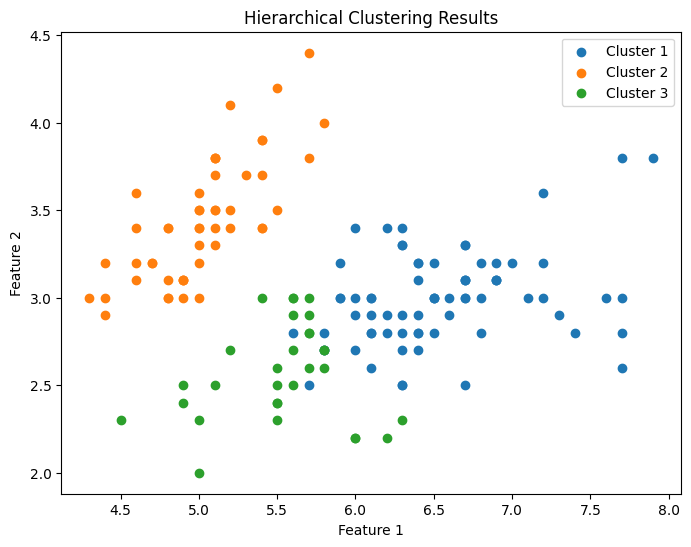

In [5]:
# Plot scatter results using first two selected feature columns
plt.figure(figsize=(8, 6))

for i in np.unique(cluster_labels):
    plt.scatter(
        X[cluster_labels == i, 0],
        X[cluster_labels == i, 1],
        label="Cluster " + str(i + 1)
    )

plt.title("Hierarchical Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()

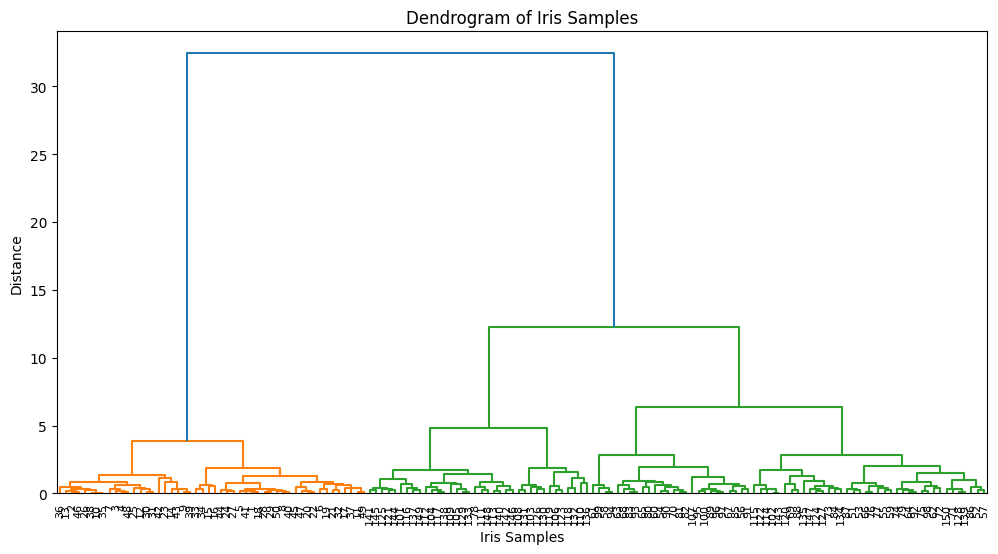

In [5]:
# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linkage(X,'ward'),
    labels=df.iloc[:, 0].values,   # use first column as sample labels
    leaf_rotation=90, # leaf labels are the labels shown at the bottom. without rotation, labels can overlap badly
    leaf_font_size=8
)

plt.title("Dendrogram of Iris Samples")
plt.xlabel("Iris Samples")
plt.ylabel("Distance")

plt.show()